# Q2-(1) 生存分析 · PySpark 实现
## 基于 Databricks 官方案例改编

> 本 Notebook 从 Databricks 官方案例改写，主要改动：
> 1. 去掉 Databricks 依赖，改用本地 CSV + PySpark
> 2. 补上了完整的数据预处理步骤
> 3. 协变量分层分析从 3 个扩展到全部 15 个

---


## 1. 案例背景与数据结构

### 1.1 数据来源
- **数据集**：IBM Telco Customer Churn（电信客户流失数据）
- **GitHub原始地址**：`https://github.com/IBM/telco-customer-churn-on-icp4d/blob/master/data/Telco-Customer-Churn.csv`
- **数据量**：约 7,032 条客户记录（经预处理过滤后）

### 1.2 生存分析核心变量
| 变量 | 含义 | 对应生存分析概念 |
|------|------|----------------|
| `tenure` | 客户在网月数（入网→流失或观察结束） | **T**（生存时间） |
| `churn` | 是否流失（1=流失，0=删失/仍在网） | **E**（事件标志） |

### 1.3 Notebook 结构
| 步骤 | 内容 |
|------|------|
| Step 1-2 | 数据下载、Schema定义、Spark加载 |
| Step 3 | Kaplan-Meier 拟合、绘图 |
| Step 4 | 协变量分层分析（15个变量） |
| Step 5 | 提取生存概率 |



In [1]:
# 安装依赖
!pip install lifelines -q
print('lifelines 安装完成')


lifelines 安装完成


In [2]:
# 导入依赖库
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from lifelines import KaplanMeierFitter
from lifelines.utils import median_survival_times
from lifelines.statistics import pairwise_logrank_test


## 下载数据

从GitHub下载IBM Telco客户流失数据集，这是业界常用的演示数据集。


In [3]:
# 下载原始 CSV 数据
import urllib.request
import os

csv_url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
csv_path = '/tmp/Telco-Customer-Churn.csv'

if not os.path.exists(csv_path):
    print('正在从 GitHub 下载 Telco Customer Churn 数据集...')
    urllib.request.urlretrieve(csv_url, csv_path)
    print(f'下载完成：{csv_path}')
else:
    print(f'文件已存在：{csv_path}')


文件已存在：/tmp/Telco-Customer-Churn.csv


## PySpark加载数据

定义Schema避免Spark自动推断，这样读取更快。然后用spark.read.csv加载数据。


In [4]:
# PySpark 加载数据
import os

# Windows环境下Spark需要这些配置
os.environ["JAVA_HOME"] = r"C:\Program Files\Java\jre-17.0.2-full"
os.environ["HADOOP_HOME"] = "E:/spark_envs/spark35"

from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, DoubleType, StringType

spark = (
    SparkSession.builder
    .appName('Survival_Analysis_Telco')
    .master('local[*]')
    .config('spark.driver.memory', '4g')
    .config('spark.hadoop.hadoop.security.authentication', 'simple')
    .config('spark.hadoop.hadoop.security.authorization', 'simple')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('WARN')

# 定义 Schema
schema = StructType([
    StructField('customerID',       StringType()),
    StructField('gender',           StringType()),
    StructField('seniorCitizen',   DoubleType()),
    StructField('partner',          StringType()),
    StructField('dependents',       StringType()),
    StructField('tenure',           DoubleType()),
    StructField('phoneService',     StringType()),
    StructField('multipleLines',    StringType()),
    StructField('internetService', StringType()),
    StructField('onlineSecurity',  StringType()),
    StructField('onlineBackup',     StringType()),
    StructField('deviceProtection',StringType()),
    StructField('techSupport',      StringType()),
    StructField('streamingTV',      StringType()),
    StructField('streamingMovies',  StringType()),
    StructField('contract',         StringType()),
    StructField('paperlessBilling', StringType()),
    StructField('paymentMethod',    StringType()),
    StructField('monthlyCharges',   DoubleType()),
    StructField('totalCharges',     DoubleType()),
    StructField('churnString',      StringType()),
])

bronze_df = (
    spark.read
    .format('csv')
    .schema(schema)
    .option('header', 'true')
    .load(csv_path)
)

print(f'原始数据：{bronze_df.count()} 行 x {len(bronze_df.columns)} 列')
bronze_df.printSchema()


原始数据：7043 行 x 21 列
root
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- seniorCitizen: double (nullable = true)
 |-- partner: string (nullable = true)
 |-- dependents: string (nullable = true)
 |-- tenure: double (nullable = true)
 |-- phoneService: string (nullable = true)
 |-- multipleLines: string (nullable = true)
 |-- internetService: string (nullable = true)
 |-- onlineSecurity: string (nullable = true)
 |-- onlineBackup: string (nullable = true)
 |-- deviceProtection: string (nullable = true)
 |-- techSupport: string (nullable = true)
 |-- streamingTV: string (nullable = true)
 |-- streamingMovies: string (nullable = true)
 |-- contract: string (nullable = true)
 |-- paperlessBilling: string (nullable = true)
 |-- paymentMethod: string (nullable = true)
 |-- monthlyCharges: double (nullable = true)
 |-- totalCharges: double (nullable = true)
 |-- churnString: string (nullable = true)



## 数据预处理

做了三件事：把churn的Yes/No转成1/0；只保留月付合同客户（流失最频繁）；只保留开通互联网服务的客户。


In [5]:
# 数据预处理
from pyspark.sql.functions import col, when

silver_df = (
    bronze_df
    .withColumn('churn',
        when(col('churnString') == 'Yes', 1.0)
        .when(col('churnString') == 'No',  0.0)
        .otherwise(None))
    .drop('churnString')
    .filter(col('contract') == 'Month-to-month')
    .filter(col('internetService') != 'No')
    .filter(col('churn').isNotNull())
)

print(f'预处理后：{silver_df.count()} 行')
print(f'流失客户数：{silver_df.filter(col("churn") == 1.0).count()}')

silver_df.select('customerID', 'tenure', 'churn', 'contract', 'internetService').show(5)


预处理后：3351 行


流失客户数：1556


+----------+------+-----+--------------+---------------+
|customerID|tenure|churn|      contract|internetService|
+----------+------+-----+--------------+---------------+
|7590-VHVEG|   1.0|  0.0|Month-to-month|            DSL|
|3668-QPYBK|   2.0|  1.0|Month-to-month|            DSL|
|9237-HQITU|   2.0|  1.0|Month-to-month|    Fiber optic|
|9305-CDSKC|   8.0|  1.0|Month-to-month|    Fiber optic|
|1452-KIOVK|  22.0|  0.0|Month-to-month|    Fiber optic|
+----------+------+-----+--------------+---------------+
only showing top 5 rows


## 转成pandas

lifelines库不能直接用Spark DataFrame，需要转成本地pandas格式再分析。


In [6]:
# 转为 pandas（lifelines 不支持直接用 Spark DataFrame）
telco_pd = silver_df.toPandas()

print(f'数据集大小：{telco_pd.shape[0]} 行')
print(f'流失客户数：{int(telco_pd["churn"].sum())} / {len(telco_pd)}')
print(f'流失率：{telco_pd["churn"].mean()*100:.2f}%')


数据集大小：3351 行
流失客户数：1556 / 3351
流失率：46.43%


## 定义生存分析变量

T是生存时间（tenure，在网月数），C是事件标志（1=流失，0=删失/仍在网）。


In [7]:
# 定义生存分析变量
T = telco_pd['tenure']
C = telco_pd['churn'].astype(float)

print(f'T 缺失值：{T.isna().sum()}')
print(f'C 缺失值：{C.isna().sum()}')
print(f'T 范围：[{T.min()}, {T.max()}] 月')


T 缺失值：0
C 缺失值：0
T 范围：[1.0, 72.0] 月


## Kaplan-Meier拟合

用KMFitter.fit()拟合生存曲线，得到中位生存时间——也就是一半客户流失的时间点。


In [8]:
# Kaplan-Meier 拟合
kmf = KaplanMeierFitter()
kmf.fit(T, C)

print(f'中位生存时间：{kmf.median_survival_time_} 个月')


中位生存时间：34.0 个月


## 绘制生存曲线

把整体生存曲线画出来，可以看到客户流失随时间变化的趋势。


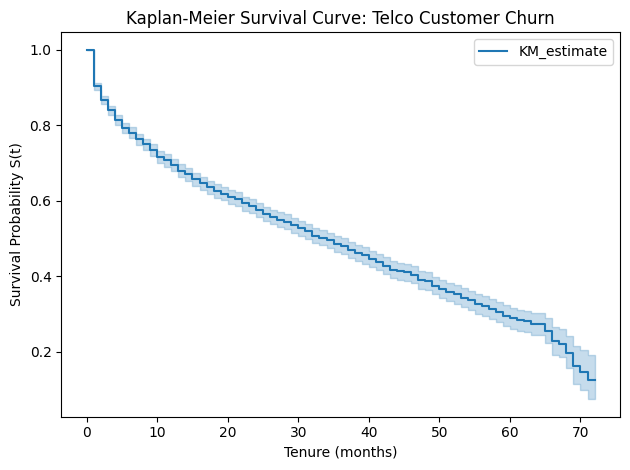

In [9]:
# 绘制生存曲线
kmf.plot(title='Kaplan-Meier Survival Curve: Telco Customer Churn')
plt.xlabel('Tenure (months)')
plt.ylabel('Survival Probability S(t)')
plt.tight_layout()
plt.show()


## 定义辅助函数

后面分层分析会用到这两个函数：plot_km()按分组画KM曲线，print_logrank()做统计检验判断曲线差异是否显著。


In [10]:
# 辅助函数
def plot_km(col, data=telco_pd, T=T, C=C):
    """按分类变量分层绘制 KM 曲线"""
    ax = plt.subplot(111)
    for r in data[col].unique():
        ix = data[col] == r
        kmf.fit(T[ix], C[ix], label=r)
        kmf.plot(ax=ax)
    plt.title(f'Kaplan-Meier Curves by {col}')
    plt.xlabel('Tenure (months)')
    plt.ylabel('Survival Probability')
    plt.tight_layout()
    plt.show()

def print_logrank(col, data=telco_pd):
    """Log-Rank 检验"""
    log_rank = pairwise_logrank_test(
        data['tenure'], data[col], data['churn'].astype(float)
    )
    print(f'\n=== Log-Rank Test: {col} ===')
    print(log_rank.summary)
    return log_rank


## 2. 协变量分层分析

对 15 个变量分别执行分层分析：`gender, seniorCitizen, partner, dependents, phoneService, multipleLines, internetService, streamingTV, streamingMovies, onlineSecurity, onlineBackup, deviceProtection, techSupport, paperlessBilling, paymentMethod`


### gender: 性别（阴性对照 — 预期 p > 0.05）

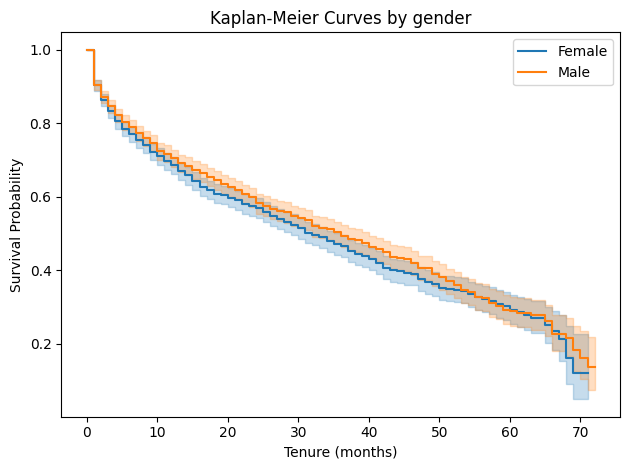


=== Log-Rank Test: gender ===
             test_statistic         p  -log2(p)
Female Male        2.038938  0.153317  2.705414


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
             test_statistic    p  -log2(p)
Female Male            2.04 0.15      2.71

In [11]:
plot_km("gender")
print_logrank("gender")

### seniorCitizen: 是否老年人

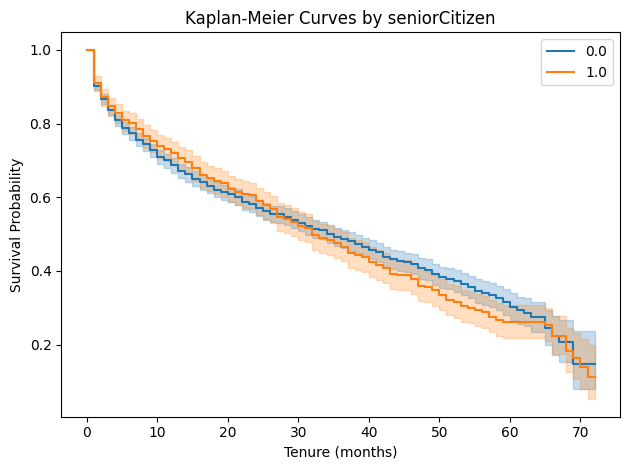


=== Log-Rank Test: seniorCitizen ===
         test_statistic         p  -log2(p)
0.0 1.0        0.125471  0.723174  0.467584


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
         test_statistic    p  -log2(p)
0.0 1.0            0.13 0.72      0.47

In [12]:
plot_km("seniorCitizen")
print_logrank("seniorCitizen")

### partner: 是否有配偶

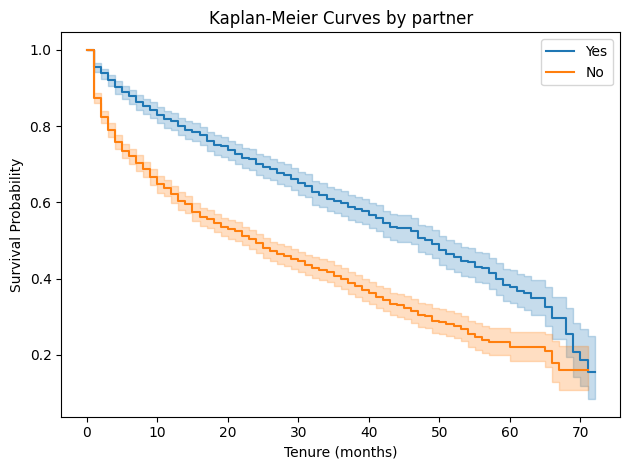


=== Log-Rank Test: partner ===
        test_statistic             p    -log2(p)
No Yes      135.758896  2.252911e-31  101.807981


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
        test_statistic      p  -log2(p)
No Yes          135.76 <0.005    101.81

In [13]:
plot_km("partner")
print_logrank("partner")

### dependents: 是否有子女

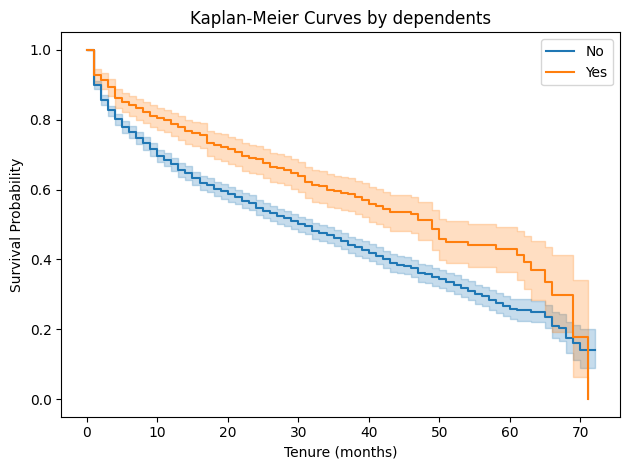


=== Log-Rank Test: dependents ===
        test_statistic             p   -log2(p)
No Yes       35.031241  3.244576e-09  28.199323


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
        test_statistic      p  -log2(p)
No Yes           35.03 <0.005     28.20

In [14]:
plot_km("dependents")
print_logrank("dependents")

### phoneService: 电话服务

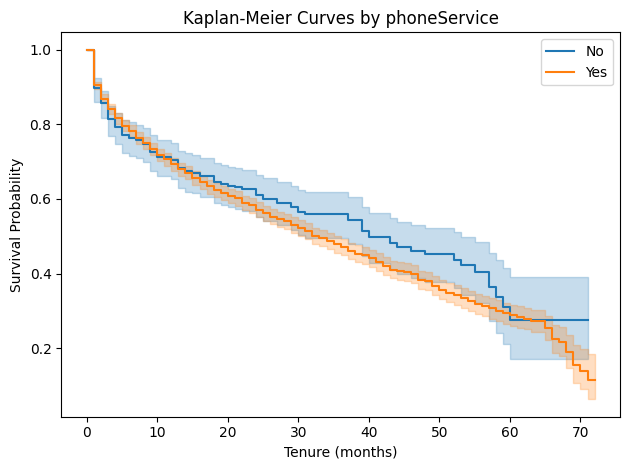


=== Log-Rank Test: phoneService ===
        test_statistic         p  -log2(p)
No Yes        1.683709  0.194432   2.36266


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
        test_statistic    p  -log2(p)
No Yes            1.68 0.19      2.36

In [15]:
plot_km("phoneService")
print_logrank("phoneService")

### multipleLines: 多线路

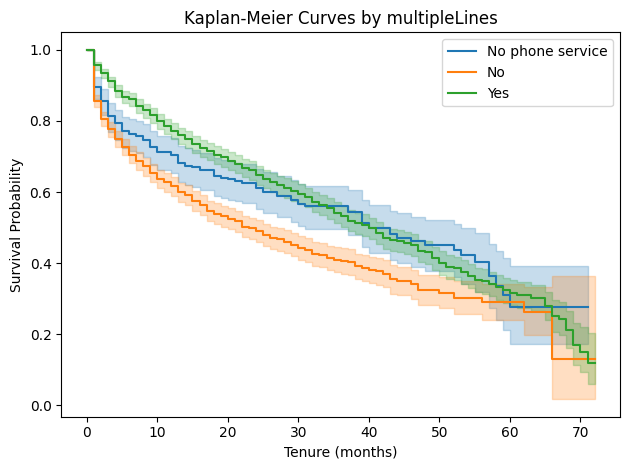


=== Log-Rank Test: multipleLines ===
                                   test_statistic             p   -log2(p)
No               No phone service       12.382712  4.333273e-04  11.172255
                 Yes                    72.358368  1.794602e-17  55.629114
No phone service Yes                     1.500291  2.206266e-01   2.180322


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
                                   test_statistic      p  -log2(p)
No               No phone service           12.38 <0.005     11.17
                 Yes                        72.36 <0.005     55.63
No phone service Yes                         1.50   0.22      2.18

In [16]:
plot_km("multipleLines")
print_logrank("multipleLines")

### internetService: 互联网服务类型

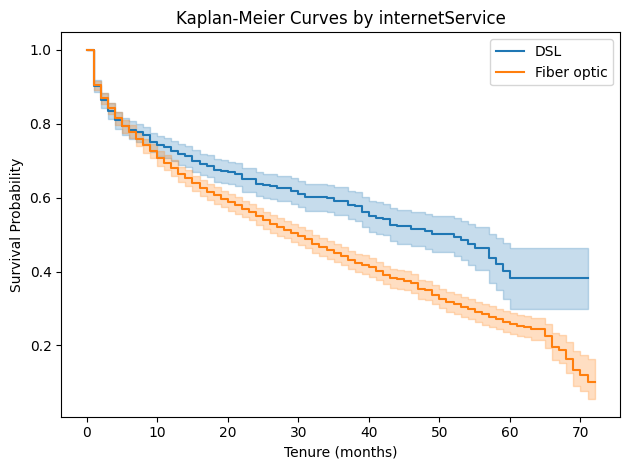


=== Log-Rank Test: internetService ===
                 test_statistic             p   -log2(p)
DSL Fiber optic       25.172866  5.241449e-07  20.863531


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
                 test_statistic      p  -log2(p)
DSL Fiber optic           25.17 <0.005     20.86

In [17]:
plot_km("internetService")
print_logrank("internetService")

### streamingTV: 流媒体电视

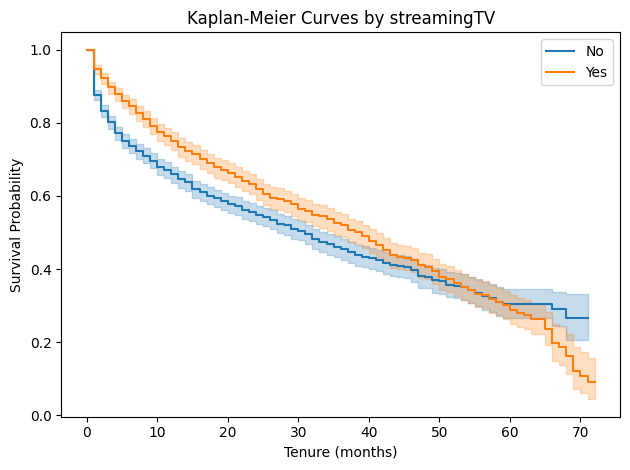


=== Log-Rank Test: streamingTV ===
        test_statistic         p   -log2(p)
No Yes        12.93926  0.000322  11.601718


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
        test_statistic      p  -log2(p)
No Yes           12.94 <0.005     11.60

In [18]:
plot_km("streamingTV")
print_logrank("streamingTV")

### streamingMovies: 流媒体电影

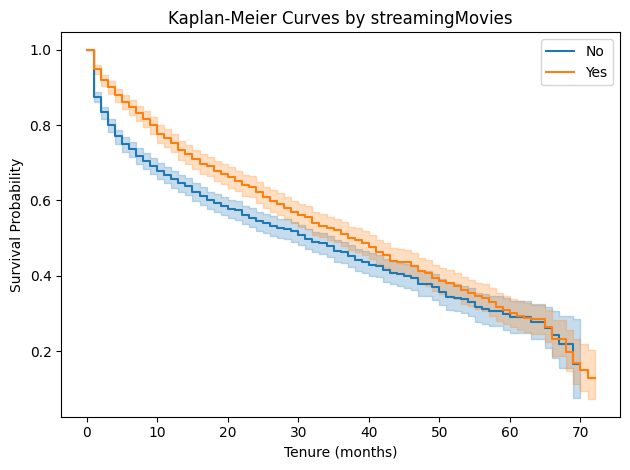


=== Log-Rank Test: streamingMovies ===
        test_statistic         p   -log2(p)
No Yes       17.941685  0.000023  15.422016


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
        test_statistic      p  -log2(p)
No Yes           17.94 <0.005     15.42

In [19]:
plot_km("streamingMovies")
print_logrank("streamingMovies")

### onlineSecurity: 在线安全（重要留存因素）

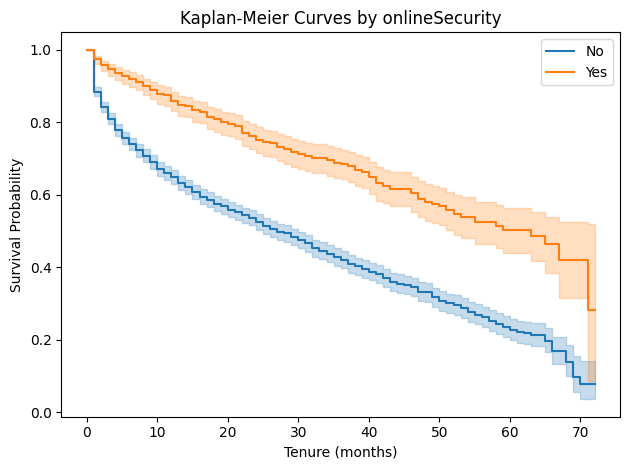


=== Log-Rank Test: onlineSecurity ===
        test_statistic             p    -log2(p)
No Yes       141.60316  1.187554e-32  106.053706


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
        test_statistic      p  -log2(p)
No Yes          141.60 <0.005    106.05

In [20]:
plot_km("onlineSecurity")
print_logrank("onlineSecurity")

### onlineBackup: 在线备份

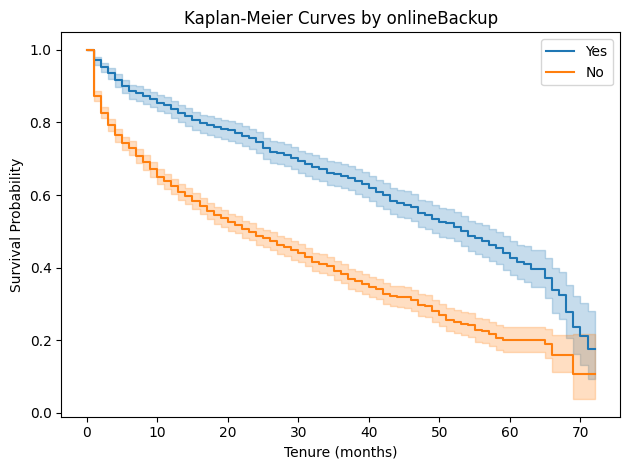


=== Log-Rank Test: onlineBackup ===
        test_statistic             p    -log2(p)
No Yes      189.482865  4.122979e-43  140.799221


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
        test_statistic      p  -log2(p)
No Yes          189.48 <0.005    140.80

In [21]:
plot_km("onlineBackup")
print_logrank("onlineBackup")

### deviceProtection: 设备保护

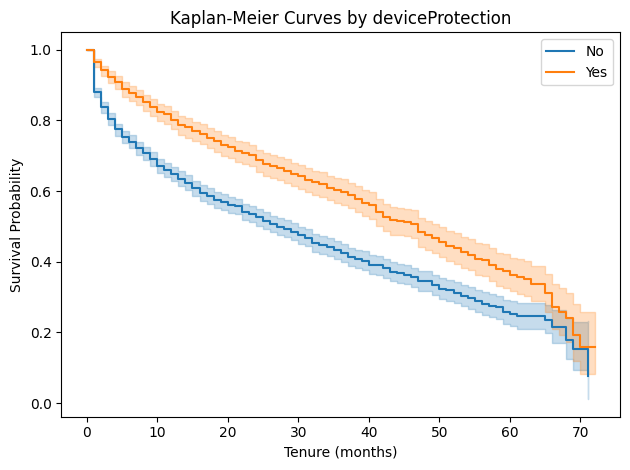


=== Log-Rank Test: deviceProtection ===
        test_statistic             p   -log2(p)
No Yes       71.496825  2.777047e-17  54.999226


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
        test_statistic      p  -log2(p)
No Yes           71.50 <0.005     55.00

In [22]:
plot_km("deviceProtection")
print_logrank("deviceProtection")

### techSupport: 技术支持

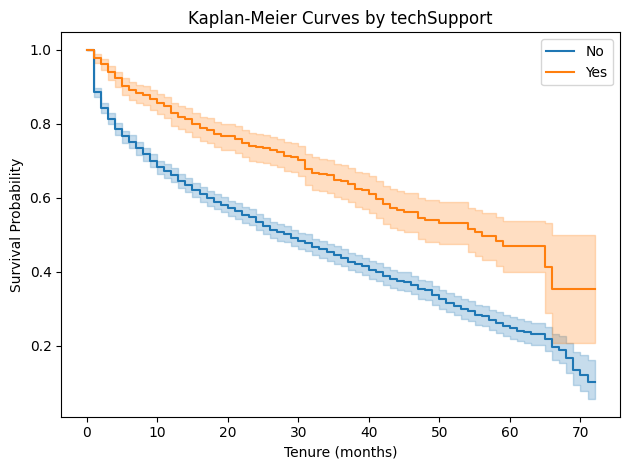


=== Log-Rank Test: techSupport ===
        test_statistic             p   -log2(p)
No Yes       90.430334  1.916059e-21  68.822348


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
        test_statistic      p  -log2(p)
No Yes           90.43 <0.005     68.82

In [23]:
plot_km("techSupport")
print_logrank("techSupport")

### paperlessBilling: 无纸化账单

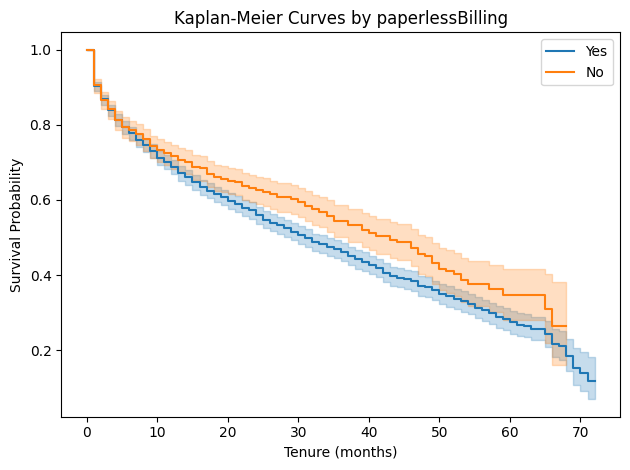


=== Log-Rank Test: paperlessBilling ===
        test_statistic         p  -log2(p)
No Yes        8.340802  0.003876  8.011049


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
        test_statistic      p  -log2(p)
No Yes            8.34 <0.005      8.01

In [24]:
plot_km("paperlessBilling")
print_logrank("paperlessBilling")

### paymentMethod: 支付方式

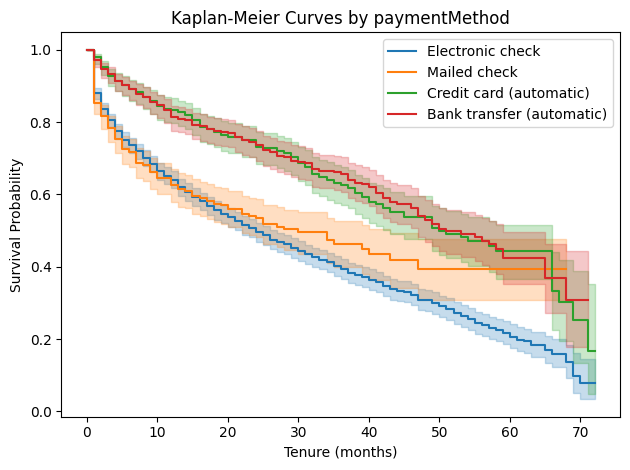


=== Log-Rank Test: paymentMethod ===
                                                   test_statistic  \
Bank transfer (automatic) Credit card (automatic)        0.061543   
                          Electronic check              91.191889   
                          Mailed check                  43.536998   
Credit card (automatic)   Electronic check              79.991082   
                          Mailed check                  39.684613   
Electronic check          Mailed check                   0.898320   

                                                              p   -log2(p)  
Bank transfer (automatic) Credit card (automatic)  8.040732e-01   0.314601  
                          Electronic check         1.303937e-21  69.377616  
                          Mailed check             4.160192e-11  34.484559  
Credit card (automatic)   Electronic check         3.761035e-19  61.205504  
                          Mailed check             2.984678e-10  31.641706  
Electronic check

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
                                                   test_statistic      p  -log2(p)
Bank transfer (automatic) Credit card (automatic)            0.06   0.80      0.31
                          Electronic check                  91.19 <0.005     69.38
                          Mailed check                      43.54 <0.005     34.48
Credit card (automatic)   Electronic check                  79.99 <0.005     61.21
                          Mailed check                      39.68 <0.005     31.64
Electronic check          Mailed check                       0.90   0.34      1.54

In [25]:
plot_km("paymentMethod")
print_logrank("paymentMethod")

## 3. 中位生存时间及其置信区间

### 3.1 全体客户中位生存时间

In [26]:
# 中位生存时间 95% 置信区间
ci = median_survival_times(kmf.confidence_interval_survival_function_)
print('=== 中位生存时间 95% 置信区间 ===')
print(ci)

# 按互联网类型分组计算中位生存时间
print('\n=== 各互联网服务类型的中位生存时间 ===')
for service in telco_pd['internetService'].unique():
    ix = telco_pd['internetService'] == service
    kmf_sub = KaplanMeierFitter()
    kmf_sub.fit(T[ix], C[ix])
    print(f'{service}: {kmf_sub.median_survival_time_} 个月')


=== 中位生存时间 95% 置信区间 ===
     Bank transfer (automatic)_lower_0.95  \
0.5                                  47.0   

     Bank transfer (automatic)_upper_0.95  
0.5                                  59.0  

=== 各互联网服务类型的中位生存时间 ===
DSL: 52.0 个月
Fiber optic: 30.0 个月


## 4. 提取生存概率表

用 `.survival_function_at_times()` 提取特定时间点的生存概率，可用于客户生命周期建模。


In [27]:
# 提取生存概率表
def get_survival_probs(col, val, data=telco_pd, T=T, C=C):
    """提取指定协变量子集的生存函数"""
    ix = data[col] == val
    kmf_sub = KaplanMeierFitter()
    kmf_sub.fit(T[ix], C[ix], label=f'{col}={val}')
    return kmf_sub

# DSL 和 Fiber optic 客户的前 10 个月生存概率
sp_dsl   = get_survival_probs('internetService', 'DSL')
sp_fiber = get_survival_probs('internetService', 'Fiber optic')

print('=== DSL 客户前 10 个月生存概率 ===')
print(pd.DataFrame(sp_dsl.survival_function_at_times(range(0, 10))))

print('\n=== Fiber optic 客户前 10 个月生存概率 ===')
print(pd.DataFrame(sp_fiber.survival_function_at_times(range(0, 10))))


=== DSL 客户前 10 个月生存概率 ===
   internetService=DSL
0             1.000000
1             0.902698
2             0.864380
3             0.834702
4             0.810522
5             0.794352
6             0.783900
7             0.776362
8             0.768486
9             0.750833

=== Fiber optic 客户前 10 个月生存概率 ===
   internetService=Fiber optic
0                     1.000000
1                     0.904605
2                     0.869243
3                     0.841957
4                     0.815118
5                     0.793455
6                     0.778639
7                     0.757999
8                     0.741271
9                     0.726456


## 5. Kaplan-Meier 的局限性与后续方法

### 5.1 Kaplan-Meier 的局限
- **仅支持单变量（univariate）分析**：一次只能看一个变量的影响
- **无法同时控制多个混杂变量**：年龄、收入、服务类型无法同时纳入

### 5.2 解决方法：Cox 比例风险回归（Cox Proportional Hazards）

Cox 模型可以同时纳入多个协变量，估计每个协变量的**风险比（HR）**：

$$h(t) = h_0(t) \times \exp(\beta_1 X_1 + \beta_2 X_2 + ...)$$

| 符号 | 含义 |
|------|------|
| $h(t)$ | t 时刻的瞬时风险率（hazard） |
| $h_0(t)$ | 基准风险率（所有协变量为 0 时） |
| $\exp(\beta_i)$ | 风险比（HR），>1 表示风险增加，<1 表示风险降低 |

> 完整的 Cox 模型实现见 Databricks 案例 `03_cox_proportional_hazards.py`。

In [28]:
# 关闭 Spark Session
spark.stop()
print('分析完成。')


分析完成。
